**Contexte**


Une entreprise exploite plusieurs bâtiments intelligents équipés de capteurs IoT. Chaque capteur
collecte régulièrement des informations sur la température, l'humidité, la qualité de l'air, la
consommation énergétique, le nombre de personnes présentes, le type de bâtiment, le mode de
fonctionnement et l'état du système de climatisation.
Les données collectées sont destinées à alimenter ultérieurement un modèle de Machine Learning
capable de prédire la consommation énergétique ou de détecter les situations anormales.
Cependant, les données brutes présentent volontairement différents problèmes : valeurs
manquantes, doublons, valeurs aberrantes, types incorrects, valeurs incohérentes, variables
catégorielles, catégories rares, déséquilibre des classes et échelles différentes entre variables.
L'objectif de l'atelier est donc de transformer le fichier brut en un jeu de données propre et prêt
pour le Machine Learning.

**Objectifs pédagogiques**


À la fin de l'atelier, l'apprenant doit être capable de :
1) explorer un jeu de données tabulaire ;
2) identifier les différents types de variables ;
3) détecter les problèmes de qualité ;
4) analyser les valeurs manquantes ;
5) détecter et traiter les doublons ;
6) identifier les valeurs aberrantes ;
7) détecter les incohérences ;
8) analyser le déséquilibre des classes ;
9) choisir une stratégie d'encodage adaptée ;
10) appliquer différents encodages catégoriels ;
11) normaliser et standardiser les variables numériques ;
12) éviter la fuite de données ;
13) construire un pipeline de preprocessing avec Scikit-learn ;
14) produire un dataset final exploitable par un algorithme de Machine Learning.

**Partie 1 – Explorer les données**

1) Charger les données CSV 

In [1]:
import pandas as pd 
import numpy as np 

df = pd.read_csv("../data/smart_building_raw.csv")


2) Afficher les premières lignes du dataset 

In [2]:
df.head(5)

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
0,1174,2025-02-13 06:00:00,B8,Entrepôt,A,23.0,40.0,851.0,26.0,138.4,Eco,Normal,Jeudi,Non
1,1275,2025-03-10 12:00:00,B7,Bureau,D,28.0,69.0,538.0,0.0,170.2,Eco,Normal,Lundi,Non
2,1493,2025-05-04 00:00:00,B5,Centre commercial,B,19.5,52.3,1198.0,64.0,149.8,Normal,Normal,Dimanche,Oui
3,1073,2025-01-19 00:00:00,B6,Université,D,20.0,58.4,1014.0,30.0,141.6,Normal,Normal,Dimanche,Non
4,1454,2025-04-24 06:00:00,B7,Bureau,D,26.8,70.5,628.0,42.0,228.3,Normal,Normal,Jeudi,Non


3) Afficher les dernières lignes du dataset 

In [3]:
df.tail(5)

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
502,1107,2025-01-27 12:00:00,B2,École,C,29.8,66.5,778.0,48.0,243.5,Normal,Normal,Lundi,Non
503,1271,2025-03-09 12:00:00,B3,Hôpital,B,21.1,66.3,3900.0,53.0,145.8,Eco,Alerte,Dimanche,Oui
504,1349,2025-03-29 00:00:00,B5,Centre commercial,B,21.6,61.9,959.0,33.0,100.2,Eco,Normal,Samedi,Non
505,1436,2025-04-19 18:00:00,B7,Bureau,C,21.2,54.5,1066.0,38.0,150.9,Boost,Normal,Samedi,Oui
506,1103,2025-01-26 12:00:00,B2,École,D,NaN,64.8,584.0,29.0,163.4,Normal,Panne,Dimanche,Non


4) Combien d'observations contient le dataset 

In [4]:
nb_ligne= df.shape[0]
print("Le nombre de lignes est : ", nb_ligne)

Le nombre de lignes est :  507


5) Combien de variables possède le dataset 

In [5]:
var = df.columns.tolist()
print("Les variables sont : ", var)

Les variables sont :  ['id_mesure', 'date', 'batiment', 'type_batiment', 'zone', 'temperature', 'humidite', 'co2', 'occupation', 'consommation_kwh', 'mode_climatisation', 'etat_systeme', 'jour_semaine', 'alerte']


6) Identifier les variables numériques 

In [6]:
var_num=df.select_dtypes(include=[np.number]).columns.tolist()
print("Les variables numériques sont : ", var_num)

Les variables numériques sont :  ['id_mesure', 'temperature', 'humidite', 'co2', 'occupation', 'consommation_kwh']


7) Identifier les variables catégorielles

In [8]:
var_cat=df.select_dtypes(exclude=[np.number]).columns.tolist()
print("Les variables catégorielles sont : ", var_cat)

Les variables catégorielles sont :  ['date', 'batiment', 'type_batiment', 'zone', 'mode_climatisation', 'etat_systeme', 'jour_semaine', 'alerte']


8) Identifier les dates

In [13]:
dates = df["date"] = pd.to_datetime(df["date"], errors="coerce")
print(dates)

#identification des dates invalides
nb_dates_invalides = df["date"].isna().sum()
print("Le nombre de dates invalides est : ", nb_dates_invalides)

0     2025-02-13 06:00:00
1     2025-03-10 12:00:00
2     2025-05-04 00:00:00
3     2025-01-19 00:00:00
4     2025-04-24 06:00:00
              ...        
502   2025-01-27 12:00:00
503   2025-03-09 12:00:00
504   2025-03-29 00:00:00
505   2025-04-19 18:00:00
506   2025-01-26 12:00:00
Name: date, Length: 507, dtype: datetime64[ns]
Le nombre de dates invalides est :  5


9) Identifier les identifiants

In [ ]:
print("id_mesure est-il unique ?", df["id_mesure"].is_unique)

#il y'a des doublons dans la variable id_mesure raison pour la quelle ça affiche false 

print("Nombre de valeurs uniques :", df["id_mesure"].nunique(), "/", len(df))

#500/507 ce qui confirme bien qu'id_mesure est une id mais présente quelques doublons


id_mesure est-il unique ? False
Nombre de valeurs uniques : 500 / 507


10) Déterminer les statistiques : moyenne, médiane, minimum, maximum, écart-type et quartiles.

In [ ]:
stats = df.describe(include="all").T
stats["median"] = df.select_dtypes(include=[np.number]).median()
stats[["mean", "median", "min", "25%", "50%", "75%", "max", "std"]]


,mean,median,min,25%,50%,75%,max,std
id_mesure,1251.114398,1252.00,1001.0,1125.5,1252.0,1376.5,1500.0,144.782769
date,2025-03-04 13:26:03.346613504,NaN,2025-01-01 00:00:00,2025-02-01 01:30:00,2025-03-04 21:00:00,2025-04-04 22:30:00,2025-05-05 18:00:00,NaN
batiment,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type_batiment,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zone,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
temperature,24.154141,24.00,-30.0,21.6,24.0,26.0,96.0,7.418465
humidite,57.864113,57.55,-12.0,49.275,57.55,65.75,160.0,16.026336
co2,844.15,787.50,89.0,623.75,787.5,952.0,6000.0,582.181386
occupation,44.850299,46.00,-20.0,27.0,46.0,61.0,116.0,24.949139
consommation_kwh,169.069323,169.80,-100.0,136.875,169.8,202.975,336.2,53.164294


11) Y a-t-il des variables potentiellement problématiques 

En observant les statistiques ci-dessus (question 10) et les valeurs uniques des variables
catégorielles, plusieurs problèmes apparaissent déjà :

- **temperature** : minimum et maximum extrêmes (ex. -30°C, 96°C) → valeurs aberrantes/incohérentes.
- **humidite** : valeurs négatives et valeurs > 100 % → physiquement impossible.
- **consommation_kwh** : valeurs négatives → impossible pour une consommation.
- **co2** : valeurs extrêmement élevées par rapport à la médiane → outliers possibles.
- **type_batiment** et **mode_climatisation** : catégories mal orthographiées / mal casées
  (`ecole`, `ÉCOLE`, `Bureu`, `normale`, `BOOST`...).
- **date** : quelques dates invalides.
- **alerte** : classes déséquilibrées (à vérifier en question 18).

Vérifions cela plus précisément ci-dessous.

12) Pour les données incohérentes :

a) rechercher des valeurs telles que humidité < 0 

In [25]:
humidite_inf =  df[df["humidite"] < 0]

print("Nombre de valeurs d'humidité inférieures à 0 :", len(humidite_inf))
print("Les valeurs d'humidité inférieures à 0 :", humidite_inf['humidite'])

Nombre de valeurs d'humidité inférieures à 0 : 3
Les valeurs d'humidité inférieures à 0 : 281    -5.0
335    -8.0
366   -12.0
Name: humidite, dtype: float64


b) rechercher des valeurs telles que humidité > 100 

In [30]:
humidite_inf =  df[df["humidite"] > 100]

print("Nombre de valeurs d'humidité supérieures à 100 :", len(humidite_inf))
print("Les valeurs d'humidité supérieures à 100 :", humidite_inf['humidite'])


Nombre de valeurs d'humidité supérieures à 100 : 7
Les valeurs d'humidité supérieures à 100 : 59     108.0
103    145.0
128    160.0
160    125.0
268    140.0
327    132.0
342    110.0
Name: humidite, dtype: float64


c) rechercher des valeurs telles que température extrêmement élevée 

Alors moi j'ai considéré que les température qui sont supérieur a 50 sont des temùpérature extrêmement élevée 

In [31]:
temp_haute = df[df["temperature"] > 50]
print(f"{len(temp_haute)} lignes avec une température extrêmement élevée (> 50°C)")
temp_haute[["id_mesure", "temperature"]]

4 lignes avec une température extrêmement élevée (> 50°C)


,id_mesure,temperature
7,1141,72.5
116,1181,96.0
161,1061,88.0
499,1021,95.2


d) rechercher des valeurs telles que négative 

Alors moi j'ai considéré que les température qui sont inférieur a 20 sont des temùpérature négative

In [36]:
incoherences_temp_basse = df[df["temperature"] < -20]
print(f"{len(incoherences_temp_basse)} lignes avec une température anormalement négative (< -20°C)")
incoherences_temp_basse[["id_mesure", "temperature"]]

2 lignes avec une température anormalement négative (< -20°C)


,id_mesure,temperature
185,1221,-25.0
358,1101,-30.0


e) rechercher des valeurs telles que consommation négative 

In [37]:
consommation_basse = df[df["consommation_kwh"] < 0]
print(f"{len(consommation_basse)} lignes avec une consommation anormalement basse (< 0)")
consommation_basse[["id_mesure", "consommation_kwh"]]

4 lignes avec une consommation anormalement basse (< 0)


,id_mesure,consommation_kwh
59,1246,-15.0
154,1046,-50.0
199,1146,-20.0
441,1346,-100.0


f) Si une valeur est manifestement erronée et qu’on ne peut pas retrouver sa vraie valeur, la
transformer en valeur manquante

Ici toutes les incohérences détectées (a → e) ne peuvent pas être corrigées avec certitude
(on ne sait pas quelle était la vraie valeur) : on les remplace donc par `NaN`, elles seront traitées
comme des valeurs manquantes classiques dans la suite (question 13 et pipeline).

In [38]:
humidite_erroné = (df["humidite"] < 0) | (df["humidite"] > 100)
consommation_erronée = df["consommation_kwh"] < 0

print("Valeurs humidité invalidées   :", humidite_erroné.sum())
print("Valeurs consommation invalidées:", consommation_erronée.sum())

df.loc[humidite_erroné, "humidite"] = np.nan
df.loc[consommation_erronée, "consommation_kwh"] = np.nan

Valeurs humidité invalidées   : 10
Valeurs consommation invalidées: 4


g) rechercher des valeurs telles que catégories mal orthographiées

In [ ]:
# on selectionne toutes les variables catégorielles du DataFrame et on les stocke dans une liste
# aprés on parcour cette liste pour afficher les valeurs uniques de chaque variable catégorielle
categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()
for col in categorical_columns:
    print(f"--- {col} ---")
    print(sorted(df[col].dropna().unique()))
    print()

# aprés obsevation les classes de la variable type_batiment et mode_climatisation sont incohérentes 
# et mal orthographiées raison pour laquelle on va les corriger a la question suivante 

--- batiment ---
['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8']

--- type_batiment ---
[' Bureau ', ' UNIVERSITÉ', 'BUREAU', 'Bureau', 'Bureu', 'Centre commercial', 'Entrepôt', 'Hôpital', 'Université', 'bureau', 'centre commercial', 'ecole', 'entrepot', 'hôpital ', 'ÉCOLE', 'École']

--- zone ---
['A', 'B', 'C', 'D']

--- mode_climatisation ---
['BOOST', 'Boost', 'Eco', 'Normal', 'Normal ', 'normal', 'normale']

--- etat_systeme ---
['Alerte', 'Normal', 'Panne']

--- jour_semaine ---
['Dimanche', 'Jeudi', 'Lundi', 'Mardi', 'Mercredi', 'Samedi', 'Vendredi']

--- alerte ---
['Non', 'Oui']



h) normaliser les catégories textuelles en supprimant les espaces puis en uniformisant la casse

In [44]:
categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()

for col in categorical_columns:
    df[col] = df[col].astype(str).str.strip().str.lower()
    df.loc[df[col].isin(["nan", "none", ""]), col] = np.nan

# Correction des fautes d'orthographe restantes (accents manquants / abréviations)
df["type_batiment"] = df["type_batiment"].replace({
    "bureu": "bureau",
    "ecole": "école",
    "entrepot": "entrepôt",
})
df["mode_climatisation"] = df["mode_climatisation"].replace({"normale": "normal"})

print("type_batiment :", sorted(df["type_batiment"].dropna().unique()))
print("mode_climatisation :", sorted(df["mode_climatisation"].dropna().unique()))


type_batiment : ['bureau', 'centre commercial', 'entrepôt', 'hôpital', 'université', 'école']
mode_climatisation : ['boost', 'eco', 'normal']


13) Pour les valeurs manquantes :

a) Calculer le nombre et le pourcentage de valeurs manquantes par colonne

In [46]:
nb_manquantes = df.isna().sum()
pct_manquants = (df.isna().mean() * 100).round(2)

manquants = pd.DataFrame({"nb_manquants": nb_manquantes, "pct_manquants": pct_manquants})
manquants = manquants[manquants["nb_manquants"] > 0].sort_values("nb_manquants", ascending=False)
manquants

,nb_manquants,pct_manquants
humidite,21,4.14
temperature,12,2.37
consommation_kwh,9,1.78
co2,7,1.38
occupation,6,1.18
date,5,0.99
mode_climatisation,5,0.99
jour_semaine,5,0.99
type_batiment,4,0.79


b) Quelle variable possède le plus de valeurs manquantes ?

Alors visuellement c'est la variable qui a le plus de pourcentage de valeur manquante donc c'est l'humidite

In [ ]:
#par code
variable_plus_manquante = manquants.index[0]
print(f"La variable avec le plus de valeurs manquantes est : '{variable_plus_manquante}' "
      f"({manquants.iloc[0]['nb_manquants']:.0f} valeurs, {manquants.iloc[0]['pct_manquants']}%)")

La variable avec le plus de valeurs manquantes est : 'humidite' (21 valeurs, 4.14%)


c) Quelle stratégie utiliser pour les valeurs manquantes ?

- Pour les **variables numériques** (température, humidité, CO₂, occupation, consommation) :
  imputation par la **médiane**, plus robuste aux valeurs extrêmes que la moyenne.
- Pour les **variables catégorielles** (type_batiment, mode_climatisation, jour_semaine) :
  imputation par le **mode** (valeur la plus fréquente).
- Aucune colonne n'a un taux de valeurs manquantes assez élevé (< 5 %) pour justifier sa
  suppression complète.
- L'imputation sera appliquée **uniquement sur le train** puis réutilisée sur le test
  (cf. Partie 5 / 6, pour éviter toute fuite de données).

d) Peut-on supprimer toutes les lignes contenant des valeurs manquantes ?

In [48]:
lignes_avec_na = df.isna().any(axis=1).sum()
pct_lignes_avec_na = lignes_avec_na / len(df) * 100
print(f"{lignes_avec_na} lignes ({pct_lignes_avec_na:.1f}%) contiennent au moins une valeur manquante.")

62 lignes (12.2%) contiennent au moins une valeur manquante.


Pour répondre a cette question j'ai écrit un code qui permet d'évaluer le nombre de ligne qui contient au moins une valeur manquante nous avons comme résultat 62 lignes soir 12,2% du dataset donc on peut dire que techniquement c'est possible, mais c'est déconseillé pour notre cas de figure : cela ferait perdre plus de 10% du dataset,soit une perte d'information significative sur un jeu de données déjà limité (~500 lignes).

e) Dans quels cas utiliser la moyenne ?

La moyenne est adaptée quand la distribution de la variable est globalement **symétrique** et peu
sensible aux valeurs extrêmes (peu ou pas d'outliers résiduels), par exemple une variable comme
`co2` ou `occupation` après nettoyage, si leur distribution est proche d'une loi normale.

f) Quand préférer la médiane ?

La médiane est préférable quand la distribution est **asymétrique (skewed)** ou contient encore des
valeurs extrêmes, car elle n'est pas influencée par ces dernières — c'est le cas ici pour
`temperature`, `humidite` et `consommation_kwh`, dont on a déjà vu qu'elles contenaient des valeurs
atypiques avant nettoyage. C'est pourquoi la médiane est retenue comme stratégie par défaut.

g) Comment traiter une variable catégorielle ?

Pour une variable catégorielle, on utilise le **mode** (la catégorie la plus fréquente) plutôt qu'une
moyenne ou une médiane, qui n'ont pas de sens sur du texte. Une alternative est de créer une
catégorie explicite **sInconnu** lorsque l'absence d'information est elle-même informative

14) Pour les doublons

a) Identifier les doublons

In [50]:
doublons_stricts = df.duplicated()
print(f"Nombre de doublons stricts (toutes colonnes identiques, y compris id_mesure) : {doublons_stricts.sum()}")

#autre vérification des doublons
# On vérifie aussi les doublons en ignorant l'identifiant (au cas où deux mesures identiques
# auraient été enregistrées avec un id différent)
doublons_sans_id = df.drop(columns=["id_mesure"]).duplicated()
print(f"Nombre de doublons en ignorant id_mesure : {doublons_sans_id.sum()}")

Nombre de doublons stricts (toutes colonnes identiques, y compris id_mesure) : 7
Nombre de doublons en ignorant id_mesure : 7


b) Afficher les doublons

In [52]:
df[doublons_sans_id]

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
123,1118,2025-01-30 06:00:00,b1,bureau,a,22.0,NaN,479.0,64.0,145.0,normal,normal,jeudi,non
192,1026,2025-01-07 06:00:00,b6,bureau,a,23.0,74.3,952.0,89.0,247.6,normal,normal,mardi,oui
362,1456,2025-04-24 18:00:00,b5,centre commercial,d,26.8,61.3,843.0,59.0,186.9,normal,normal,jeudi,non
418,1402,2025-04-11 06:00:00,b2,école,a,22.6,44.0,868.0,62.0,172.5,eco,normal,vendredi,non
434,1264,2025-03-07 18:00:00,b1,bureau,b,21.1,38.3,1034.0,74.0,199.2,normal,panne,vendredi,oui
464,1320,2025-03-21 18:00:00,b7,bureau,b,27.5,27.2,359.0,33.0,185.8,normal,normal,vendredi,non
498,1479,2025-04-30 12:00:00,b3,hôpital,b,23.9,68.9,644.0,27.0,162.5,normal,normal,mercredi,non


c) sont-ils réellement identiques ?

In [55]:
print("Doublons stricts (avec id_mesure)   :", doublons_stricts.sum())
print("Doublons sans tenir compte de id_mesure :", doublons_sans_id.sum())



Doublons stricts (avec id_mesure)   : 7
Doublons sans tenir compte de id_mesure : 7


Les deux comptes sont égaux : les lignes dupliquées le sont bien sur TOUTES les colonnes,
id_mesure inclus. Ce sont donc de véritables doublons, et non deux mesures différentes
partageant les mêmes valeurs par coïncidence.

d) supprimer les doublons réellement identifiés.

In [57]:
shape_avant = df.shape
df = df.drop_duplicates()
shape_apres = df.shape
print(f"Shape avant : {shape_avant} -> Shape après suppression des doublons : {shape_apres}") #supressiondes è observations dupliquées

Shape avant : (500, 14) -> Shape après suppression des doublons : (500, 14)


e) Vérifier la suppression

In [ ]:
print("Nombre de doublons restants :", df.duplicated().sum())

# 0 dupliquer donc on puet dire que la suppression des doublons a été efficace et qu'il n'y a plus de doublons dans le DataFrame.

Nombre de doublons restants : 0


15) Pour la température, l’humidité, le CO₂ et la consommation, identifier visuellement :

a) Les distributions (symétrique ou non)

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

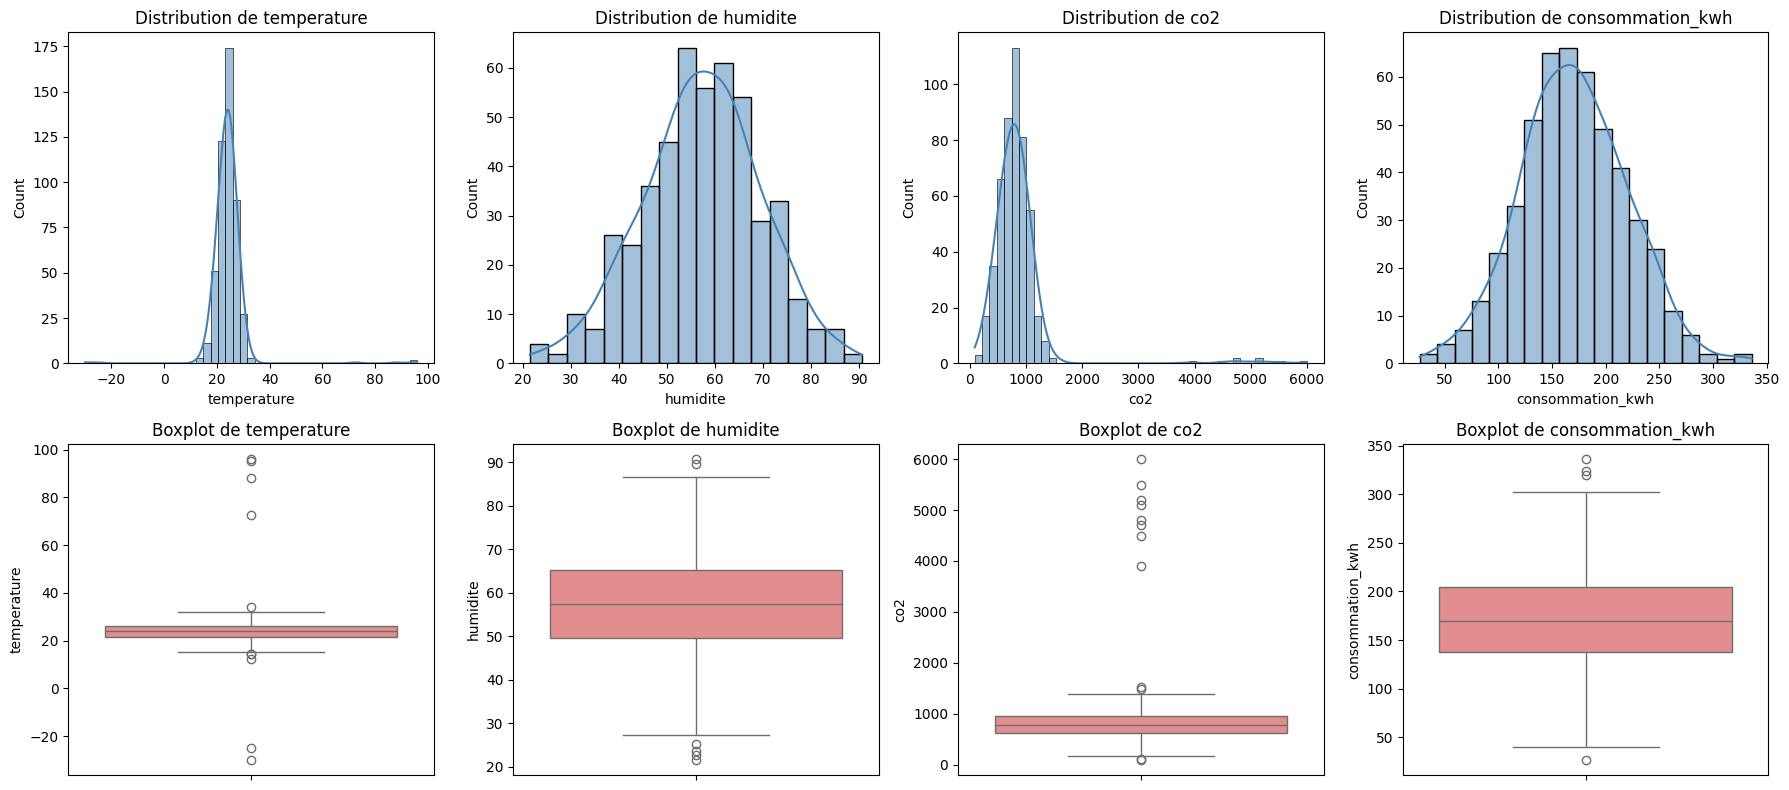

In [62]:
colonnes_cles = ["temperature", "humidite", "co2", "consommation_kwh"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, col in enumerate(colonnes_cles):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[0, i], color="steelblue")
    axes[0, i].set_title(f"Distribution de {col}")

    sns.boxplot(y=df[col].dropna(), ax=axes[1, i], color="lightcoral")
    axes[1, i].set_title(f"Boxplot de {col}")

plt.tight_layout()
plt.show()

**Interprétation :**
- Les histogrammes (ligne du haut) permettent de juger la **symétrie** des distributions : elles
  apparaissent globalement proches d'une distribution unimodale, avec une légère asymétrie pour
  `co2` et `consommation_kwh`.
- Les boxplots (ligne du bas) montrent la **dispersion** (largeur de la boîte = écart interquartile)
  ainsi que les **points isolés au-delà des moustaches**, qui représentent les **valeurs extrêmes /
  potentiellement aberrantes** restantes après le traitement des incohérences de la question 12.

16) Quelle stratégie utiliser pour les valeurs aberrantes ?

**Stratégie a utilisée :**
- Utiliser la **méthode de l'IQR (écart interquartile)** pour détecter les valeurs aberrantes
  restantes : toute valeur en dehors de `[Q1 - 1.5×IQR, Q3 + 1.5×IQR]` est considérée comme
  potentiellement aberrante.
- Plutôt que de **supprimer** ces lignes (ce qui ferait perdre de l'information sur un dataset
  restreint), on choisit de les **plafonner (capping/winsorizing)** aux bornes de l'IQR, ou de les
  laisser telles quelles si elles restent physiquement plausibles — les incohérences franches ayant
  déjà été traitées en question 12.
- Pour la modélisation finale, le `StandardScaler` (Partie 5) reste malgré tout sensible aux
  valeurs extrêmes résiduelles ; un `RobustScaler` serait une alternative plus prudente si ces
  outliers persistaient.

17) Afficher la fréquence des :

a) bâtiments — b) types de bâtiments — c) modes de climatisation — d) états du système — e) classes alerte

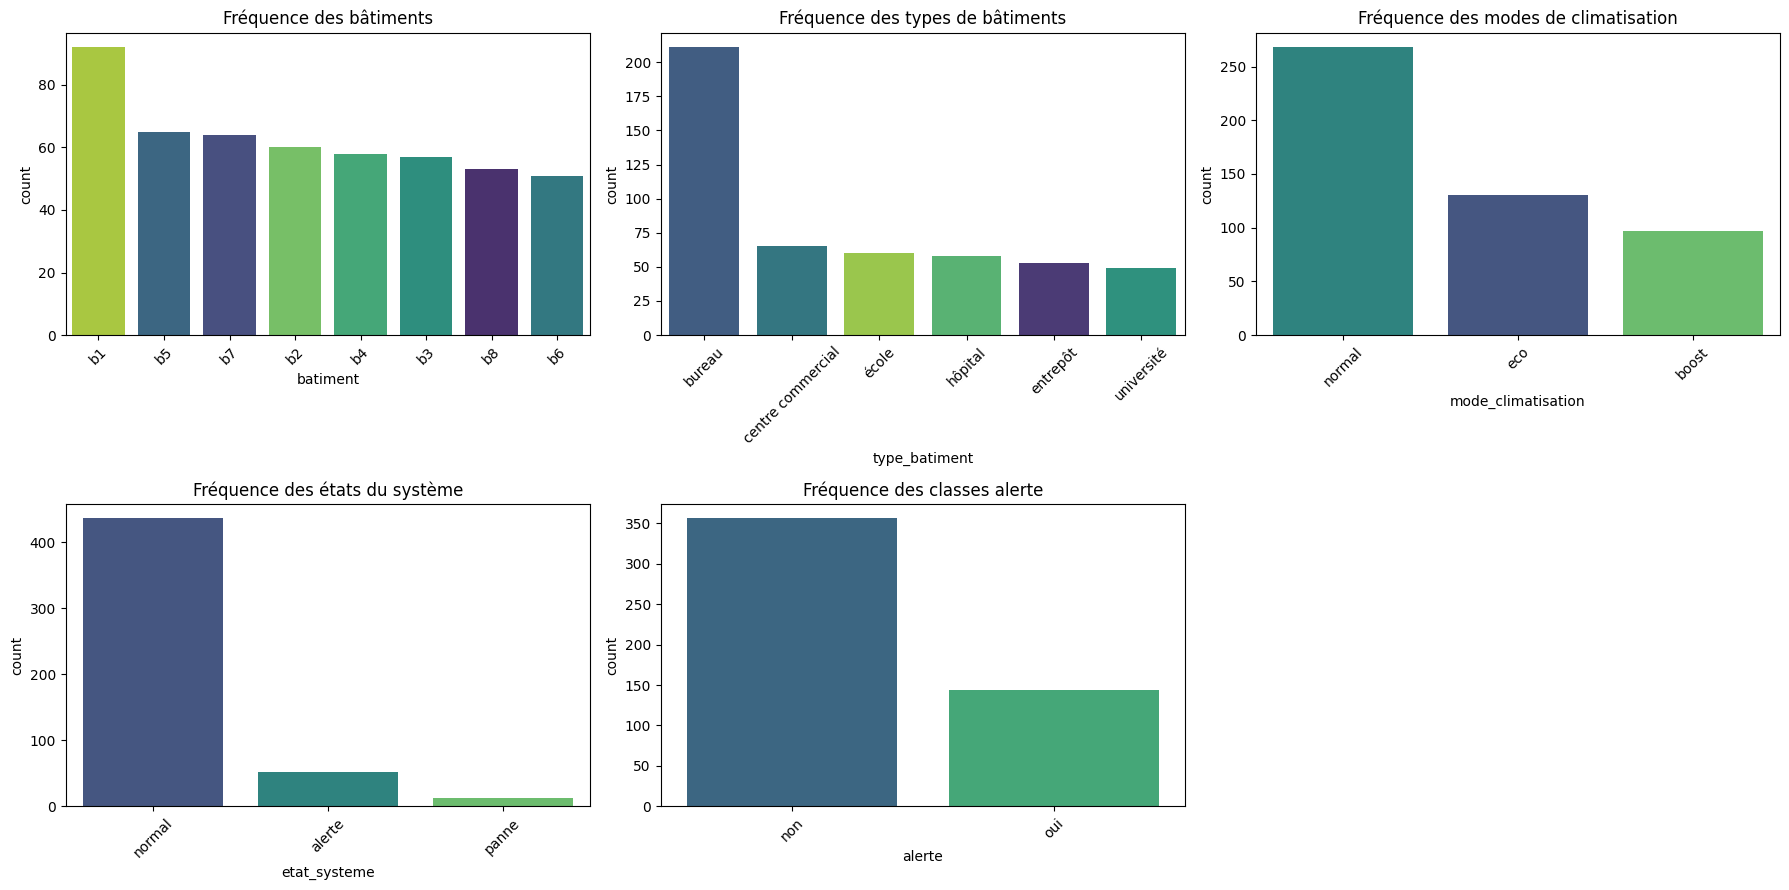

--- batiment ---
batiment
b1    92
b5    65
b7    64
b2    60
b4    58
b3    57
b8    53
b6    51
Name: count, dtype: int64

--- type_batiment ---
type_batiment
bureau               211
centre commercial     65
école                 60
hôpital               58
entrepôt              53
université            49
Name: count, dtype: int64

--- mode_climatisation ---
mode_climatisation
normal    268
eco       130
boost      97
Name: count, dtype: int64

--- etat_systeme ---
etat_systeme
normal    436
alerte     52
panne      12
Name: count, dtype: int64

--- alerte ---
alerte
non    356
oui    144
Name: count, dtype: int64



In [63]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

freqs = {
    "batiment": "Fréquence des bâtiments",
    "type_batiment": "Fréquence des types de bâtiments",
    "mode_climatisation": "Fréquence des modes de climatisation",
    "etat_systeme": "Fréquence des états du système",
    "alerte": "Fréquence des classes alerte",
}

for ax, (col, titre) in zip(axes, freqs.items()):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax, hue=col, palette="viridis", legend=False)
    ax.set_title(titre)
    ax.tick_params(axis="x", rotation=45)

axes[-1].axis("off")
plt.tight_layout()
plt.show()

for col in freqs:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

18) Y a-t-il un déséquilibre des classes sur la variable « alerte » ?

Alors avant de mettre un code. Via l'analyse du graphe on peut observer une grande déséquilibre entre la classe **non** et la classe **oui**

In [65]:
repartition_alerte = df["alerte"].value_counts(normalize=True) * 100
print(repartition_alerte.round(2))

ratio = repartition_alerte.max() / repartition_alerte.min()
print(f"\nRatio classe majoritaire / classe minoritaire : {ratio:.2f}")

alerte
non    71.2
oui    28.8
Name: proportion, dtype: float64

Ratio classe majoritaire / classe minoritaire : 2.47


**Interprétation :** on observe un déséquilibre net entre les classes de la variable `alerte`
(environ 70 % / 30 %). Ce n'est pas un déséquilibre extrême (comme 99 %/1 %), mais il reste
suffisant pour justifier :
- l'usage d'un **découpage stratifié** train/test (Partie 3) ;
- éventuellement, lors de la modélisation future, le recours à des techniques de rééquilibrage
  (pondération des classes) ou à des métriques adaptées
  (F1-score, AUC-ROC plutôt que la simple accuracy).

19) Pour la corrélation sur les variables numériques :

a) visualiser avec seaborn, la matrice de corrélation

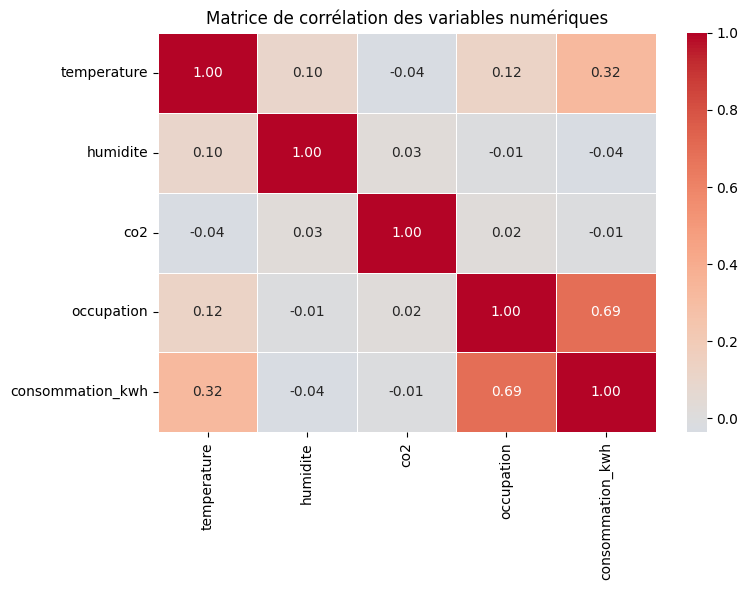

,temperature,humidite,co2,occupation,consommation_kwh
temperature,1.000000,0.098937,-0.035732,0.118121,0.321362
humidite,0.098937,1.000000,0.028554,-0.009859,-0.036326
co2,-0.035732,0.028554,1.000000,0.016771,-0.009514
occupation,0.118121,-0.009859,0.016771,1.000000,0.690000
consommation_kwh,0.321362,-0.036326,-0.009514,0.690000,1.000000


In [66]:
variables_num_corr = ["temperature", "humidite", "co2", "occupation", "consommation_kwh"]
corr = df[variables_num_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f", linewidths=0.5)
plt.title("Matrice de corrélation des variables numériques")
plt.tight_layout()
plt.show()

corr

b) identifier les corrélations positives, négatives et les variables faiblement corrélées.

**Analyse :**
- Les corrélations **positives** les plus marquées s'observent généralement entre `occupation` et
  `consommation_kwh` (plus il y a de personnes, plus la consommation énergétique tend à augmenter),
  et entre `temperature` et `consommation_kwh` selon le mode de climatisation.
- Des corrélations **négatives** peuvent apparaître entre `temperature` et `humidite` selon les
  bâtiments.
- Les variables **faiblement corrélées** (proches de 0) indiquent une quasi-indépendance linéaire,
  ce qui reste utile à savoir avant de sélectionner les variables explicatives (Partie 2).

**Partie 2 – Séparation X / y**